# Model 04: Gradient Boosting Regressor

### Objective
While Random Forest builds trees independently, Gradient Boosting builds them **sequentially**. Each new tree strictly focuses on correcting the mathematical errors (residuals) made by the previous tree, making it highly accurate but prone to overfitting if not tuned.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('evidence', exist_ok=True)

### 1. Load Datasets

In [2]:
X_train = pd.read_csv('../../../../../data/processed/X_train_scaled.csv')
X_train = X_train.fillna(X_train.mean())
y_train = pd.read_csv('../../../../../data/processed/y_train_reg.csv').squeeze()

X_val = pd.read_csv('../../../../../data/processed/X_val_scaled.csv')
y_val = pd.read_csv('../../../../../data/processed/y_val_reg.csv').squeeze()

print("Datasets loaded successfully.")

Datasets loaded successfully.


### 2. Model Training
We train 150 sequential boosting stages. We use a learning rate of `0.1` to ensure the algorithm doesn't overcorrect too aggressively.

In [3]:
gb_model = GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)

print("✅ Gradient Boosting Regressor Trained Successfully.")

✅ Gradient Boosting Regressor Trained Successfully.

### 3. Mathematical Evaluation

In [4]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100

def evaluate_regression(model, X, y_true, model_name):
    y_pred = model.predict(X)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {model_name} ---")
    print(f"MAE:  {mae:.2f}%")
    print(f"RMSE: {rmse:.2f}%")
    print(f"MAPE: {mape:.2f}%")
    print(f"R2:   {r2:.4f}\n")

print("========== TRAINING SET ==========")
evaluate_regression(gb_model, X_train, y_train, "Gradient Boosting (TRAIN)")

print("========== VALIDATION SET ==========")
evaluate_regression(gb_model, X_val, y_val, "Gradient Boosting (VAL)")

========== TRAINING SET ==========
--- Gradient Boosting (TRAIN) ---
MAE:  0.64%
RMSE: 0.81%
MAPE: 3.84%
R2:   0.9864

========== VALIDATION SET ==========
--- Gradient Boosting (VAL) ---
MAE:  6.70%
RMSE: 8.04%
MAPE: 42.50%
R2:   -0.8005



### 4. Learning Curve Analysis
Because Gradient Boosting is sequential, we can literally plot how the Training Error dropped as each of the 150 trees was added.

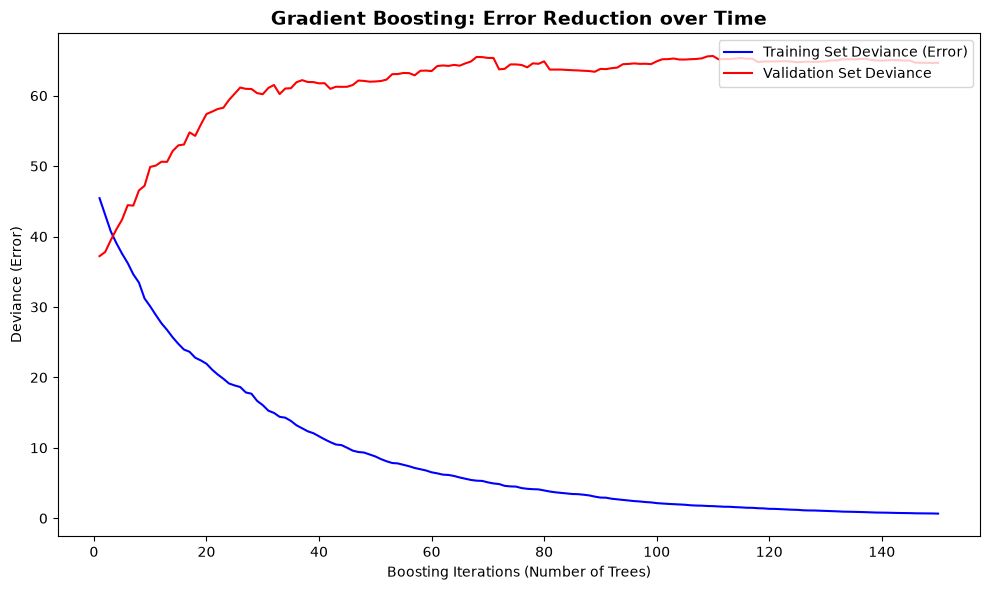

In [5]:
test_score = np.zeros((150,), dtype=np.float64)
for i, y_pred in enumerate(gb_model.staged_predict(X_val)):
    test_score[i] = mean_squared_error(y_val, y_pred)

plt.figure(figsize=(10, 6))
plt.plot(np.arange(150) + 1, gb_model.train_score_, 'b-', label='Training Set Deviance (Error)')
plt.plot(np.arange(150) + 1, test_score, 'r-', label='Validation Set Deviance')
plt.legend(loc='upper right')
plt.xlabel('Boosting Iterations (Number of Trees)')
plt.ylabel('Deviance (Error)')
plt.title('Gradient Boosting: Error Reduction over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evidence/01_gb_learning_curve.png', dpi=300)
plt.show()

### Experiment Tracking
Automatically append the metrics of this model to our global `experiment_results.csv` matrix for the final deliverable.

In [6]:
import datetime
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

val_preds = gb_model.predict(X_val)
val_mae = mean_absolute_error(y_val, val_preds)
val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
val_mape = np.mean(np.abs((y_val - val_preds) / (y_val + 1e-9))) * 100
val_r2 = r2_score(y_val, val_preds)

tracker_file = '../../../../../data/processed/experiment_results.csv'
file_exists = os.path.isfile(tracker_file)

experiment_data = pd.DataFrame({
    'Timestamp': [datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')],
    'Model_ID': ['04_gradient_boosting_regressor'],
    'Model_Type': ['Regression'],
    'Val_MAE': [val_mae],
    'Val_RMSE': [val_rmse],
    'Val_MAPE': [val_mape],
    'Val_R2': [val_r2],
    'Val_Accuracy': [np.nan],
    'Val_F1': [np.nan],
    'Val_ROCAUC': [np.nan]
})

experiment_data.to_csv(tracker_file, mode='a', header=not file_exists, index=False)
print(f"✅ Experiment logged successfully to {tracker_file}")

✅ Experiment logged successfully to ../../../../../data/processed/experiment_results.csv
